  TABLA DE PARÁMETROS ESTIMADOS
  Activo                      : SPY
  Periodo                     : 2021-01-01 → 2023-12-31
  Observaciones               : 752 retornos diarios
----------------------------------------------------------
  S₀  (precio inicial)        : $   462.58
  μ   (drift histórico)       :    11.54 %
  σ   (volatilidad)           :    17.61 %
  r   (tasa libre de riesgo)  :     4.50 %
  λ = (μ−r)/σ                 :    0.3999
  T   (horizonte)             :   1.0 año
  N   (trayectorias MC)       :   10,000
  Pasos por trayectoria       :   252

  TABLA DE RESULTADOS — PRECIOS DESCONTADOS
  S₀  (precio inicial)             : $ 462.5799
  E^P[e^(-rT) S_T]  simulado       : $ 495.5395
  E^P[e^(-rT) S_T]  teórico        : $ 496.3271
  E^Q[e^(-rT) S_T]  simulado       : $ 461.8458
  E^Q[e^(-rT) S_T]  teórico (= S₀) : $ 462.5799
----------------------------------------------------------
  |E^Q − S₀|  (error martingala)   : $ 0.7341
  |E^P − S₀|  (prima de riesgo)    : $ 

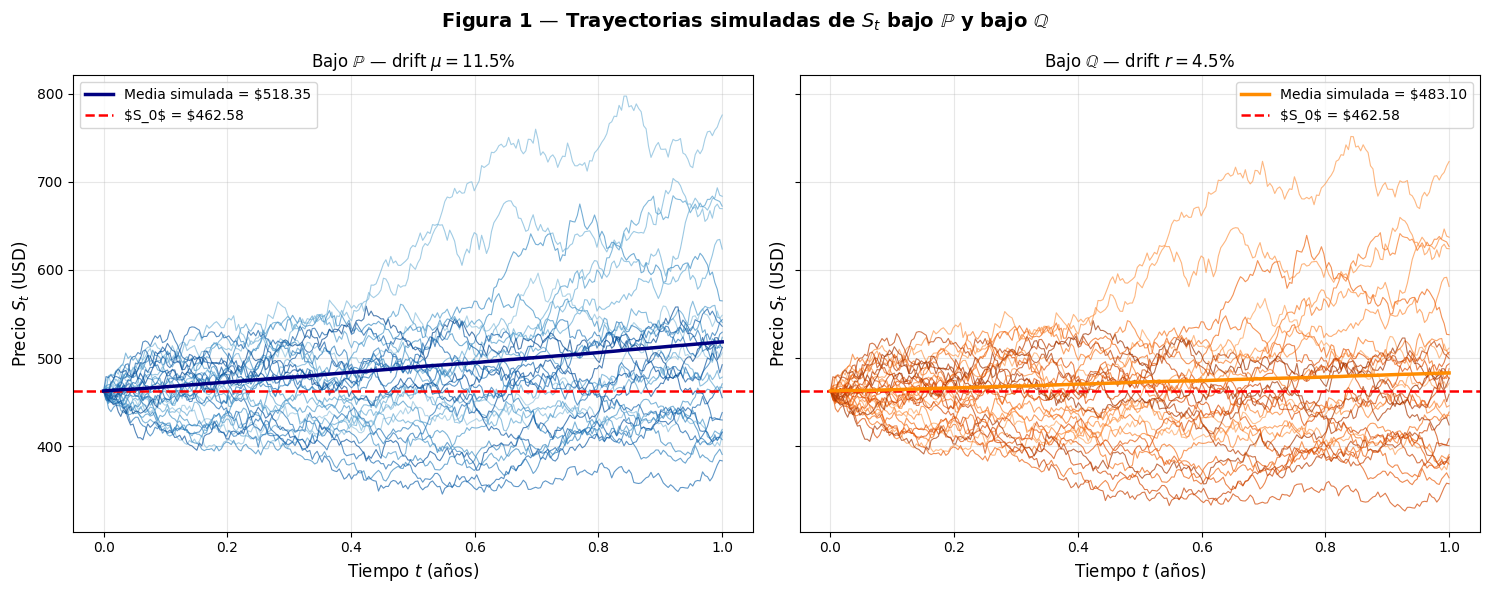

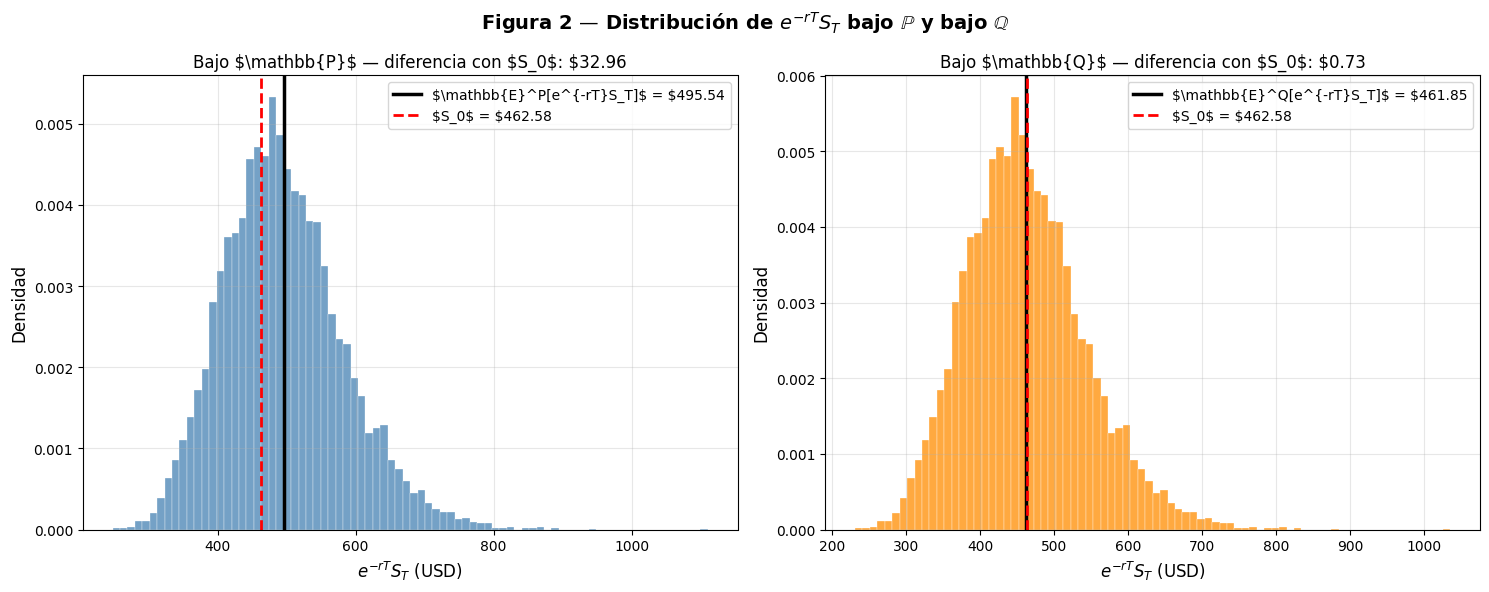

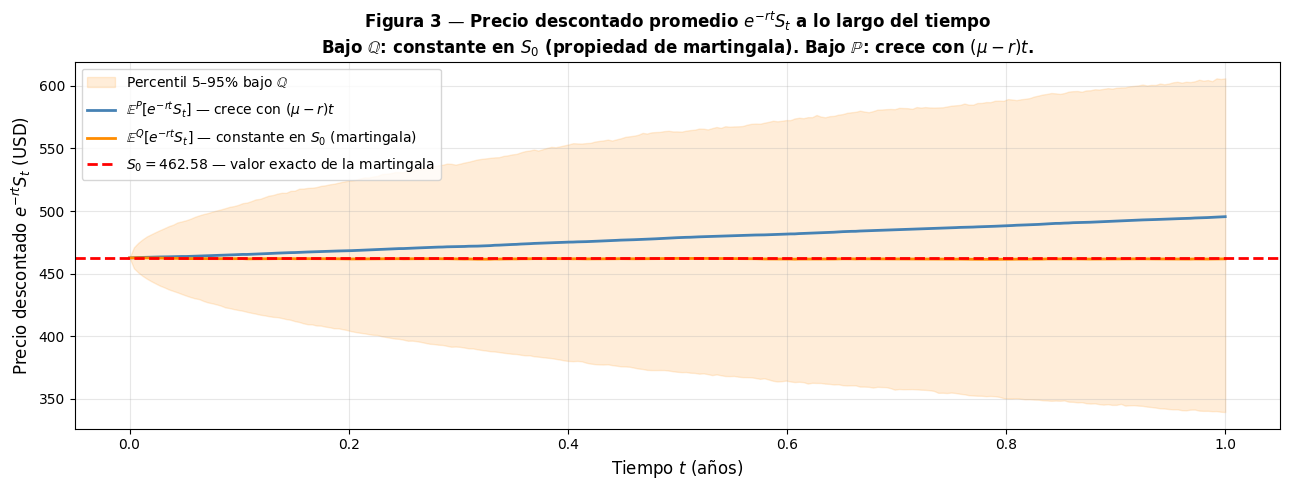

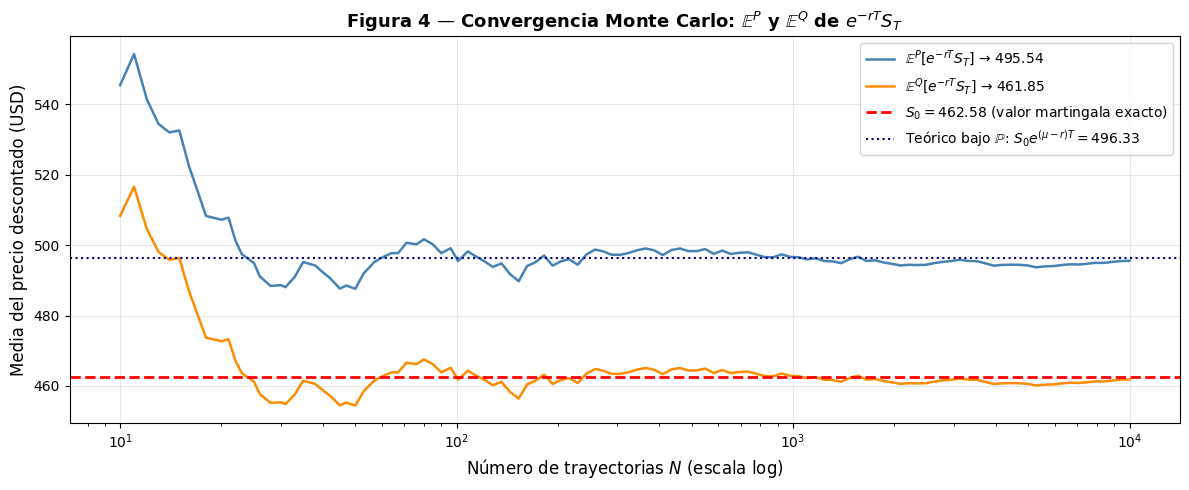

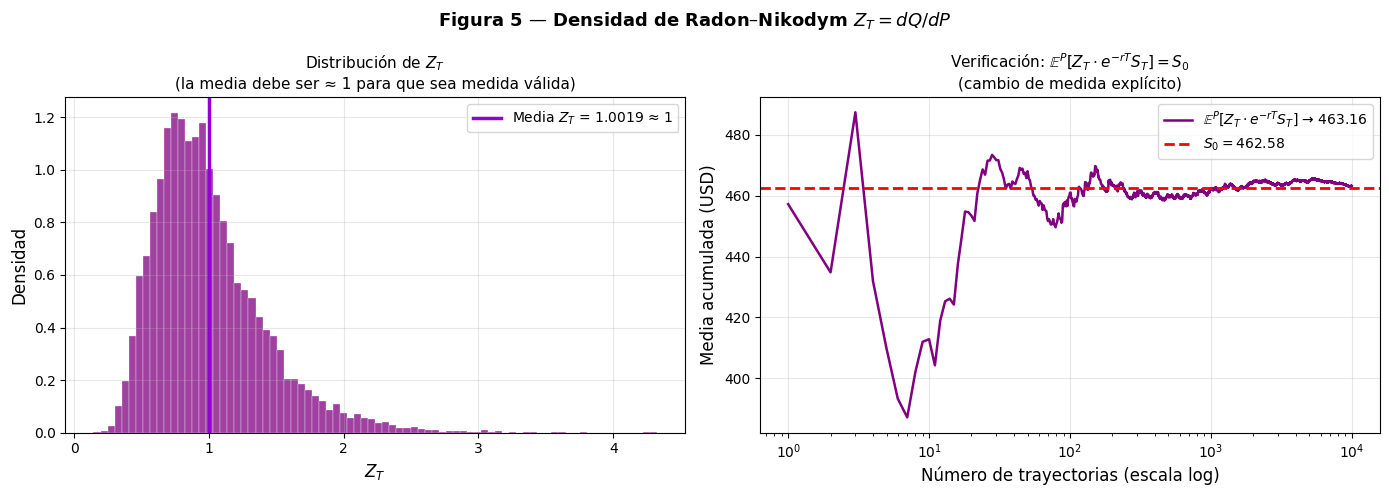


  TABLA RESUMEN COMPLETA
  S₀  (precio inicial observado)                   $ 462.5799
  μ   (drift histórico anual)                       11.5416 %
  σ   (volatilidad anual)                           17.6074 %
  r   (tasa libre de riesgo)                         4.5000 %
  λ = (μ−r)/σ  (Sharpe instantáneo)                    0.3999
  T   (vencimiento)                                   1.0 año
  N   (trayectorias Monte Carlo)                       10,000
  ───────────────────────────────────────────   ─────────────
  E^P[e^{-rT} S_T]  — simulado                     $ 495.5395
  E^P[e^{-rT} S_T]  — teórico                      $ 496.3271
  E^Q[e^{-rT} S_T]  — simulado                     $ 461.8458
  E^Q[e^{-rT} S_T]  — teórico (= S₀)               $ 462.5799
  E^P[Z_T·e^{-rT} S_T] — simulado                  $ 463.1602
  ───────────────────────────────────────────   ─────────────
  |E^Q − S₀|  (error de martingala)                  $ 0.7341
  |E^P − S₀|  (efecto prima de riesgo)      

In [ ]:
# ============================================================
#  PROYECTO 10 — Cambio de medida y martingalas en derivados
#  Opción 2: Verificación de martingala en precios descontados
#  Universidad Panamericana — Finanzas Cuantitativas
# ============================================================

# ── INSTALACIÓN ─────────────────────────────────────────────
!pip install yfinance --quiet

# ── LIBRERÍAS ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ============================================================
#  PARÁMETROS GLOBALES
# ============================================================
TICKER   = 'SPY'
START    = '2021-01-01'
END      = '2023-12-31'
T        = 1.0        # horizonte: 1 año
N_STEPS  = 252        # pasos diarios
N_PATHS  = 10_000     # trayectorias Monte Carlo
R        = 0.045      # tasa libre de riesgo anual
DAYS     = 252        # días bursátiles por año

# ============================================================
#  SECCIÓN 1 — DESCARGA Y ESTIMACIÓN DE PARÁMETROS
# ============================================================
raw    = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close'].dropna()

# Log-retornos diarios
log_ret = np.log(prices / prices.shift(1)).dropna()

# Estadísticos muestrales
mu_daily    = float(log_ret.mean())
sigma_daily = float(log_ret.std())

# Anualización con corrección de Itô
sigma_annual  = sigma_daily * np.sqrt(DAYS)
mu_log_annual = mu_daily * DAYS
mu_annual     = mu_log_annual + 0.5 * sigma_annual**2

# Precio inicial y precio de mercado del riesgo
S0  = float(prices.iloc[-1])
lam = (mu_annual - R) / sigma_annual

print("=" * 58)
print("  TABLA DE PARÁMETROS ESTIMADOS")
print("=" * 58)
print(f"  Activo                      : {TICKER}")
print(f"  Periodo                     : {START} → {END}")
print(f"  Observaciones               : {len(log_ret):,} retornos diarios")
print("-" * 58)
print(f"  S₀  (precio inicial)        : $ {S0:>8.2f}")
print(f"  μ   (drift histórico)       :   {mu_annual*100:>6.2f} %")
print(f"  σ   (volatilidad)           :   {sigma_annual*100:>6.2f} %")
print(f"  r   (tasa libre de riesgo)  :   {R*100:>6.2f} %")
print(f"  λ = (μ−r)/σ                 :   {lam:>7.4f}")
print(f"  T   (horizonte)             :   {T:.1f} año")
print(f"  N   (trayectorias MC)       :   {N_PATHS:,}")
print(f"  Pasos por trayectoria       :   {N_STEPS}")
print("=" * 58)

# ============================================================
#  SECCIÓN 2 — SIMULACIÓN MONTE CARLO BAJO P Y BAJO Q
# ============================================================
dt      = T / N_STEPS
sqrt_dt = np.sqrt(dt)

# Choques aleatorios compartidos (misma Z para P y Q)
Z = np.random.standard_normal((N_PATHS, N_STEPS))

# ── Simulación bajo P (drift = mu_annual) ───────────────────
log_S_P       = np.zeros((N_PATHS, N_STEPS + 1))
log_S_P[:, 0] = np.log(S0)

for i in range(N_STEPS):
    log_S_P[:, i+1] = (log_S_P[:, i]
                       + (mu_annual - 0.5 * sigma_annual**2) * dt
                       + sigma_annual * sqrt_dt * Z[:, i])

S_P   = np.exp(log_S_P)
S_T_P = S_P[:, -1]

# ── Simulación bajo Q (drift = R) ───────────────────────────
log_S_Q       = np.zeros((N_PATHS, N_STEPS + 1))
log_S_Q[:, 0] = np.log(S0)

for i in range(N_STEPS):
    log_S_Q[:, i+1] = (log_S_Q[:, i]
                       + (R - 0.5 * sigma_annual**2) * dt
                       + sigma_annual * sqrt_dt * Z[:, i])

S_Q   = np.exp(log_S_Q)
S_T_Q = S_Q[:, -1]

# ── Precios descontados terminales ──────────────────────────
disc_factor = np.exp(-R * T)
disc_S_T_P  = disc_factor * S_T_P
disc_S_T_Q  = disc_factor * S_T_Q

# ── Estadísticos clave ──────────────────────────────────────
E_P         = disc_S_T_P.mean()
E_Q         = disc_S_T_Q.mean()
E_P_teorico = S0 * np.exp((mu_annual - R) * T)
se_P        = disc_S_T_P.std() / np.sqrt(N_PATHS)
se_Q        = disc_S_T_Q.std() / np.sqrt(N_PATHS)

print("\n" + "=" * 58)
print("  TABLA DE RESULTADOS — PRECIOS DESCONTADOS")
print("=" * 58)
print(f"  S₀  (precio inicial)             : $ {S0:.4f}")
print(f"  E^P[e^(-rT) S_T]  simulado       : $ {E_P:.4f}")
print(f"  E^P[e^(-rT) S_T]  teórico        : $ {E_P_teorico:.4f}")
print(f"  E^Q[e^(-rT) S_T]  simulado       : $ {E_Q:.4f}")
print(f"  E^Q[e^(-rT) S_T]  teórico (= S₀) : $ {S0:.4f}")
print("-" * 58)
print(f"  |E^Q − S₀|  (error martingala)   : $ {abs(E_Q - S0):.4f}")
print(f"  |E^P − S₀|  (prima de riesgo)    : $ {abs(E_P - S0):.4f}")
print(f"  Error estándar MC bajo Q          : $ {se_Q:.4f}")
print(f"  Error estándar MC bajo P          : $ {se_P:.4f}")
print("=" * 58)

# ============================================================
#  SECCIÓN 3 — FIGURA 1: TRAYECTORIAS BAJO P Y Q
# ============================================================
N_SHOW    = 30
time_grid = np.linspace(0, T, N_STEPS + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
fig.suptitle(
    'Figura 1 — Trayectorias simuladas de $S_t$ bajo $\\mathbb{P}$ y bajo $\\mathbb{Q}$',
    fontsize=14, fontweight='bold'
)

colors_P = plt.cm.Blues(np.linspace(0.4, 0.9, N_SHOW))
colors_Q = plt.cm.Oranges(np.linspace(0.4, 0.9, N_SHOW))

for j in range(N_SHOW):
    axes[0].plot(time_grid, S_P[j], color=colors_P[j], lw=0.8, alpha=0.7)
    axes[1].plot(time_grid, S_Q[j], color=colors_Q[j], lw=0.8, alpha=0.7)

mean_P = S_P.mean(axis=0)
mean_Q = S_Q.mean(axis=0)

axes[0].plot(time_grid, mean_P, color='navy', lw=2.5,
             label=f'Media simulada = ${mean_P[-1]:.2f}', zorder=5)
axes[1].plot(time_grid, mean_Q, color='darkorange', lw=2.5,
             label=f'Media simulada = ${mean_Q[-1]:.2f}', zorder=5)

for ax in axes:
    ax.axhline(S0, color='red', lw=1.8, ls='--', label=f'$S_0$ = ${S0:.2f}')
    ax.set_xlabel('Tiempo $t$ (años)', fontsize=12)
    ax.set_ylabel('Precio $S_t$ (USD)', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_title(
    f'Bajo $\\mathbb{{P}}$ — drift $\\mu = {mu_annual*100:.1f}\\%$', fontsize=12
)
axes[1].set_title(
    f'Bajo $\\mathbb{{Q}}$ — drift $r = {R*100:.1f}\\%$', fontsize=12
)

plt.tight_layout()
plt.show()

# ============================================================
#  SECCIÓN 4 — FIGURA 2: DISTRIBUCIÓN DEL PRECIO DESCONTADO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    'Figura 2 — Distribución de $e^{-rT}S_T$ bajo $\\mathbb{P}$ y bajo $\\mathbb{Q}$',
    fontsize=14, fontweight='bold'
)

datos  = [disc_S_T_P,  disc_S_T_Q]
colores = ['steelblue', 'darkorange']
E_vals  = [E_P,  E_Q]
medidas = ['$\\mathbb{P}$', '$\\mathbb{Q}$']
letras  = ['P', 'Q']

for ax, data, color, E_val, medida, letra in zip(
        axes, datos, colores, E_vals, medidas, letras):

    ax.hist(data, bins=80, color=color, alpha=0.75,
            edgecolor='white', linewidth=0.3, density=True)
    ax.axvline(E_val, color='black', lw=2.5, ls='-',
               label=f'$\\mathbb{{E}}^{letra}[e^{{-rT}}S_T]$ = ${E_val:.2f}')
    ax.axvline(S0,    color='red',   lw=2.0, ls='--',
               label=f'$S_0$ = ${S0:.2f}')
    ax.set_title(
        f'Bajo {medida} — diferencia con $S_0$: ${abs(E_val - S0):.2f}',
        fontsize=12
    )
    ax.set_xlabel('$e^{-rT}S_T$ (USD)', fontsize=12)
    ax.set_ylabel('Densidad', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
#  SECCIÓN 5 — FIGURA 3: PRECIO DESCONTADO A LO LARGO DEL TIEMPO
# ============================================================
discount_curve = np.exp(-R * time_grid)
disc_paths_P   = S_P * discount_curve[np.newaxis, :]
disc_paths_Q   = S_Q * discount_curve[np.newaxis, :]

mean_disc_P = disc_paths_P.mean(axis=0)
mean_disc_Q = disc_paths_Q.mean(axis=0)

p5_Q  = np.percentile(disc_paths_Q, 5,  axis=0)
p95_Q = np.percentile(disc_paths_Q, 95, axis=0)

fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(time_grid, p5_Q, p95_Q,
                color='darkorange', alpha=0.15,
                label='Percentil 5–95% bajo $\\mathbb{Q}$')
ax.plot(time_grid, mean_disc_P, color='steelblue', lw=2,
        label='$\\mathbb{E}^P[e^{-rt}S_t]$ — crece con $(\\mu - r)t$')
ax.plot(time_grid, mean_disc_Q, color='darkorange', lw=2,
        label='$\\mathbb{E}^Q[e^{-rt}S_t]$ — constante en $S_0$ (martingala)')
ax.axhline(S0, color='red', lw=2, ls='--',
           label=f'$S_0 = {S0:.2f}$ — valor exacto de la martingala')

ax.set_xlabel('Tiempo $t$ (años)', fontsize=12)
ax.set_ylabel('Precio descontado $e^{-rt}S_t$ (USD)', fontsize=12)
ax.set_title(
    'Figura 3 — Precio descontado promedio $e^{-rt}S_t$ a lo largo del tiempo\n'
    'Bajo $\\mathbb{Q}$: constante en $S_0$ (propiedad de martingala). '
    'Bajo $\\mathbb{P}$: crece con $(\\mu - r)t$.',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
#  SECCIÓN 6 — FIGURA 4: CONVERGENCIA MONTE CARLO
# ============================================================
sample_sizes = np.unique(
    np.logspace(1, np.log10(N_PATHS), 120).astype(int)
)
means_P_conv = [disc_S_T_P[:n].mean() for n in sample_sizes]
means_Q_conv = [disc_S_T_Q[:n].mean() for n in sample_sizes]

fig, ax = plt.subplots(figsize=(12, 5))

ax.semilogx(sample_sizes, means_P_conv, color='steelblue', lw=1.8,
            label=f'$\\mathbb{{E}}^P[e^{{-rT}}S_T]$ → ${E_P:.2f}$')
ax.semilogx(sample_sizes, means_Q_conv, color='darkorange', lw=1.8,
            label=f'$\\mathbb{{E}}^Q[e^{{-rT}}S_T]$ → ${E_Q:.2f}$')
ax.axhline(S0, color='red', lw=2, ls='--',
           label=f'$S_0 = {S0:.2f}$ (valor martingala exacto)')
ax.axhline(E_P_teorico, color='navy', lw=1.5, ls=':',
           label=f'Teórico bajo $\\mathbb{{P}}$: '
                 f'$S_0 e^{{(\\mu-r)T}} = {E_P_teorico:.2f}$')

ax.set_xlabel('Número de trayectorias $N$ (escala log)', fontsize=12)
ax.set_ylabel('Media del precio descontado (USD)', fontsize=12)
ax.set_title(
    'Figura 4 — Convergencia Monte Carlo: '
    '$\\mathbb{E}^P$ y $\\mathbb{E}^Q$ de $e^{-rT}S_T$',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
#  SECCIÓN 7 — FIGURA 5: DENSIDAD DE RADON–NIKODYM Z_T
# ============================================================
# Recuperar B_T^P de las trayectorias simuladas
B_T_P = (np.log(S_T_P / S0)
         - (mu_annual - 0.5 * sigma_annual**2) * T) / sigma_annual

Z_T = np.exp(-lam * B_T_P - 0.5 * lam**2 * T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Figura 5 — Densidad de Radon–Nikodym $Z_T = dQ/dP$',
    fontsize=13, fontweight='bold'
)

# Panel izquierdo: histograma de Z_T
axes[0].hist(Z_T, bins=80, color='purple', alpha=0.75,
             edgecolor='white', linewidth=0.3, density=True)
axes[0].axvline(Z_T.mean(), color='darkviolet', lw=2.5,
                label=f'Media $Z_T$ = {Z_T.mean():.4f} ≈ 1')
axes[0].set_xlabel('$Z_T$', fontsize=12)
axes[0].set_ylabel('Densidad', fontsize=12)
axes[0].set_title(
    'Distribución de $Z_T$\n(la media debe ser ≈ 1 para que sea medida válida)',
    fontsize=11
)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Panel derecho: verificación E^P[Z_T * e^{-rT} S_T] = S_0
check_vals   = Z_T * disc_S_T_P
running_mean = np.cumsum(check_vals) / np.arange(1, N_PATHS + 1)

axes[1].semilogx(np.arange(1, N_PATHS + 1), running_mean,
                 color='purple', lw=1.8,
                 label=f'$\\mathbb{{E}}^P[Z_T \\cdot e^{{-rT}}S_T]$ '
                       f'→ ${running_mean[-1]:.2f}$')
axes[1].axhline(S0, color='red', lw=2, ls='--',
                label=f'$S_0 = {S0:.2f}$')
axes[1].set_xlabel('Número de trayectorias (escala log)', fontsize=12)
axes[1].set_ylabel('Media acumulada (USD)', fontsize=12)
axes[1].set_title(
    'Verificación: $\\mathbb{E}^P[Z_T \\cdot e^{-rT}S_T] = S_0$\n'
    '(cambio de medida explícito)',
    fontsize=11
)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
#  SECCIÓN 8 — TABLA RESUMEN FINAL
# ============================================================
print("\n" + "=" * 65)
print("  TABLA RESUMEN COMPLETA")
print("=" * 65)
rows = [
    ("S₀  (precio inicial observado)",       f"$ {S0:.4f}"),
    ("μ   (drift histórico anual)",           f"  {mu_annual*100:.4f} %"),
    ("σ   (volatilidad anual)",               f"  {sigma_annual*100:.4f} %"),
    ("r   (tasa libre de riesgo)",            f"  {R*100:.4f} %"),
    ("λ = (μ−r)/σ  (Sharpe instantáneo)",     f"  {lam:.4f}"),
    ("T   (vencimiento)",                     f"  {T:.1f} año"),
    ("N   (trayectorias Monte Carlo)",        f"  {N_PATHS:,}"),
    ("─" * 43,                               "─" * 13),
    ("E^P[e^{-rT} S_T]  — simulado",         f"$ {E_P:.4f}"),
    ("E^P[e^{-rT} S_T]  — teórico",          f"$ {E_P_teorico:.4f}"),
    ("E^Q[e^{-rT} S_T]  — simulado",         f"$ {E_Q:.4f}"),
    ("E^Q[e^{-rT} S_T]  — teórico (= S₀)",   f"$ {S0:.4f}"),
    ("E^P[Z_T·e^{-rT} S_T] — simulado",      f"$ {(Z_T * disc_S_T_P).mean():.4f}"),
    ("─" * 43,                               "─" * 13),
    ("|E^Q − S₀|  (error de martingala)",    f"$ {abs(E_Q - S0):.4f}"),
    ("|E^P − S₀|  (efecto prima de riesgo)", f"$ {abs(E_P - S0):.4f}"),
    ("Error estándar MC bajo Q",             f"$ {se_Q:.4f}"),
    ("Media de Z_T  (debe ser ≈ 1)",         f"  {Z_T.mean():.6f}"),
]
for k, v in rows:
    print(f"  {k:<45} {v:>13}")
print("=" * 65)

# ============================================================
#  SECCIÓN 9 — BONUS: CALL EUROPEA MC vs BLACK–SCHOLES
#  Muestra que μ no aparece en el precio de la opción
# ============================================================
print("\n" + "=" * 72)
print("  BONUS — Call europea: Monte Carlo bajo Q  vs  Black–Scholes")
print("  (μ no aparece en ninguna fórmula — sólo σ y r determinan el precio)")
print("=" * 72)
print(f"  {'Strike K':>10} | {'MC bajo Q':>10} | {'Black-Scholes':>13} "
      f"| {'|Diferencia|':>13} | Moneyness")
print("-" * 72)

for mult in [0.90, 0.95, 1.00, 1.05, 1.10]:
    K_val = S0 * mult

    # Monte Carlo bajo Q
    payoffs = np.maximum(S_T_Q - K_val, 0)
    C_MC    = disc_factor * payoffs.mean()
    se_call = disc_factor * payoffs.std() / np.sqrt(N_PATHS)

    # Black–Scholes fórmula cerrada
    d1   = (np.log(S0 / K_val) + (R + 0.5 * sigma_annual**2) * T) \
           / (sigma_annual * np.sqrt(T))
    d2   = d1 - sigma_annual * np.sqrt(T)
    C_BS = S0 * norm.cdf(d1) - K_val * np.exp(-R * T) * norm.cdf(d2)

    tag = 'ATM' if mult == 1.00 else ('ITM' if mult < 1.00 else 'OTM')
    print(f"  ${K_val:>8.2f} | ${C_MC:>8.2f}     | ${C_BS:>11.2f} "
          f"| ${abs(C_MC - C_BS):>11.4f} | {tag}")

print("=" * 72)
print("\n✅ Proyecto completado. Todas las secciones ejecutadas correctamente.")